### Analyze the Impact of Synaptic Noise on Astrocyte Wave Dynamics

Evaluate how different levels of stochastic synaptic noise influence calcium wave propagation, IP₃ signaling, and calcium decay dynamics across repeated simulation runs.

### Import Analysis and Visualization Libraries

Load the libraries required for data processing, statistical analysis, and figure generation.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")


#### Load Simulation Results

Load simulation outputs generated across multiple synaptic noise levels and assemble them into a unified dataset for analysis.

In [2]:
results_dir = "batch_results"
results = []

for fname in os.listdir(results_dir):
    if fname.endswith(".json") and fname.startswith("sigma_"):
        with open(os.path.join(results_dir, fname)) as f:
            results.append(json.load(f))

print(f"Loaded {len(results)} result files.")


Loaded 10 result files.


#### Classify Simulation Outcomes

Compute wave-propagation metrics and classify simulation outcomes into stable, transition, and failure regimes based on predefined physiological criteria.

In [3]:
df = pd.DataFrame(results)
df['sigma'] = df['sigma'].astype(float)
df['tau_ip3'] = df['tau_ip3'].astype(float)
df['tau_ca'] = df['tau_ca'].astype(float)
df['wave_speed'] = df['wave_speed'].astype(float)

# Classification zones
def classify(row):
    if row['failed']:
        return "❌ Failure"
    elif not (7 <= row['wave_speed'] <= 27 and 2 <= row['tau_ip3'] <= 7 and 1500 <= row['tau_ca'] <= 2500):
        return "Transition"
    else:
        return "Stable"

df['zone'] = df.apply(classify, axis=1)
df.head()

,sigma,trigger_pixel,wave_speed,wave_distance,tau_ip3,tau_ca,wave_reached_soma,failed,config,runtime_sec,zone
0,45000.0,"[80, 51]",25.924254,17.464249,3.135867,1898.550160,1.0,False,"{'target': 'glu_gamma_equation', 'type': 'gaus...",139.312796,Stable
1,45000.0,"[80, 51]",25.806079,17.464249,3.459570,1930.688700,1.0,False,"{'target': 'glu_gamma_equation', 'type': 'gaus...",127.006268,Stable
2,46000.0,"[80, 51]",0.000000,0.000000,0.399254,NaN,0.0,True,"{'target': 'glu_gamma_equation', 'type': 'gaus...",130.431878,❌ Failure
3,46000.0,"[80, 51]",26.769675,17.464249,3.150429,1925.183012,1.0,False,"{'target': 'glu_gamma_equation', 'type': 'gaus...",128.664743,Stable
4,47000.0,"[80, 51]",23.304844,17.464249,3.072466,1903.362980,1.0,False,"{'target': 'glu_gamma_equation', 'type': 'gaus...",126.874190,Stable


#### Visualize Noise Sensitivity Across Wave Metrics

Generate summary plots showing how synaptic noise affects calcium wave speed, IP₃ decay dynamics, and calcium decay behavior across the simulated parameter space.

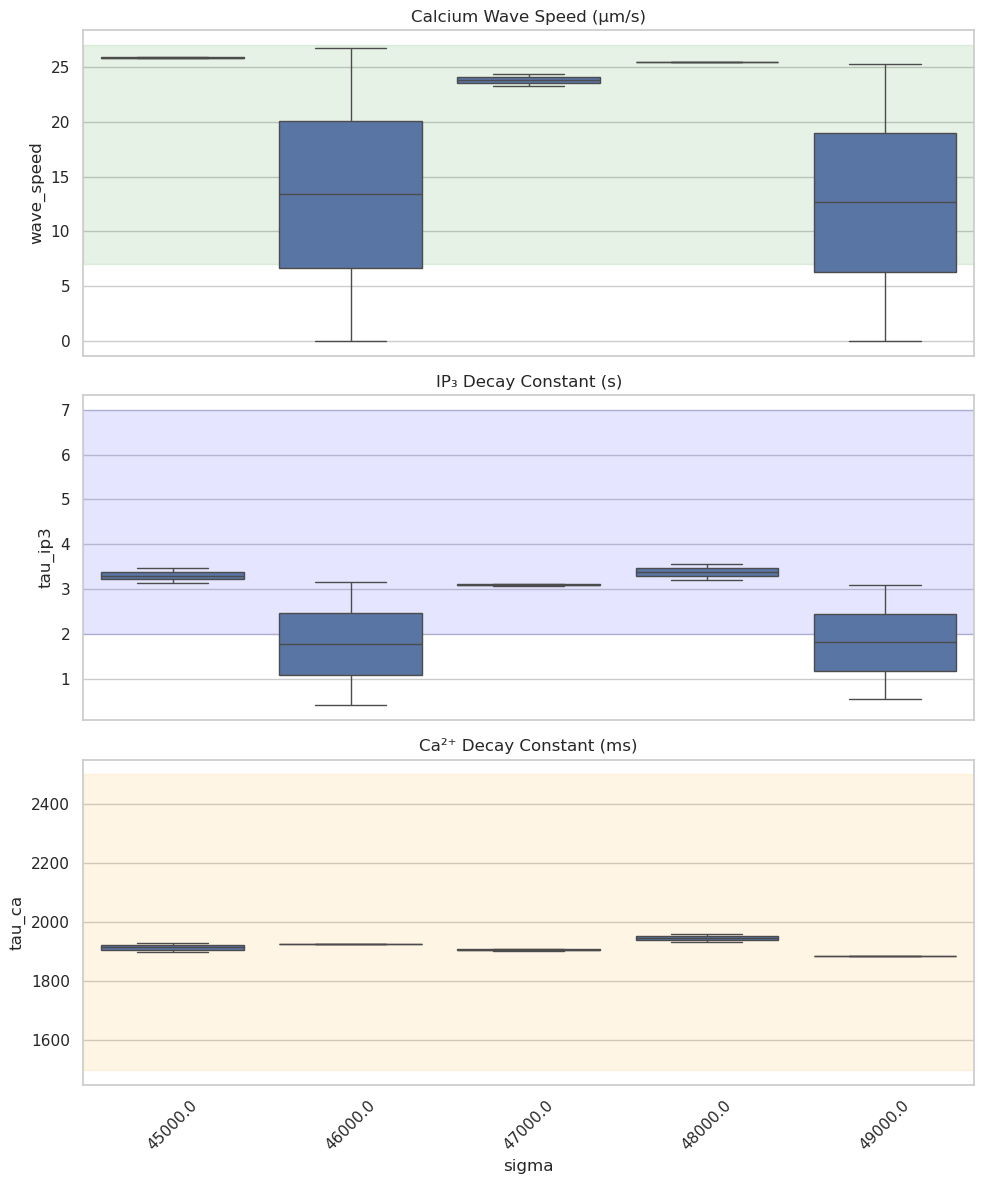

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

sns.boxplot(data=df, x="sigma", y="wave_speed", ax=axs[0])
axs[0].set_title("Calcium Wave Speed (μm/s)")
axs[0].axhspan(7, 27, color='green', alpha=0.1)

sns.boxplot(data=df, x="sigma", y="tau_ip3", ax=axs[1])
axs[1].set_title("IP₃ Decay Constant (s)")
axs[1].axhspan(2, 7, color='blue', alpha=0.1)

sns.boxplot(data=df, x="sigma", y="tau_ca", ax=axs[2])
axs[2].set_title("Ca²⁺ Decay Constant (ms)")
axs[2].axhspan(1500, 2500, color='orange', alpha=0.1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
